In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from pathlib import Path
import numpy as np
import warnings
import os

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

import sys
from mylib import genomes

In [3]:
root_dir = join(Path.home(),"projects/cp_als/second_pair/")
cd_root_dir = join(Path.home(),"projects/cp_als/second_pair/populations/output/CD")
cluster_file = "cd_population2cluster_AggCluster_k5.csv"

as_root_dir = join(Path.home(),"projects/cp_als/second_pair/populations/output/AS")

shared_genes = ["IL12B", "CARD9", "TNF", "GPR35", "ZMIZ1", "KIF21B"]
as_gene_names = ["STAT3", "HLA-B", "ERAP1"]

models = [
    SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    LinearRegression(),
    RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1),
]

# Create output directories
# csv_output_dir = "data4boxplots"
# plot_output_dir = "plots"
# os.makedirs(csv_output_dir, exist_ok=True)
# os.makedirs(plot_output_dir, exist_ok=True)

# print(f"CD: {cd_root_dir}")
# print(f"AS: {as_root_dir}")
# print(f"Cluster file: {cluster_file}")
# print(f"Shared genes: {shared_genes}")
# print(f"AS genes: {as_gene_names}")
# print(f"Models: {[m.__class__.__name__ for m in models]}")
# print(f"CSV output directory: {csv_output_dir}")
# print(f"Plot output directory: {plot_output_dir}")

In [4]:
cluster_df = pd.read_csv(cluster_file)
print("Cluster assignments:")
print(cluster_df.head(10))

clusters = {}
for cluster_id in sorted(cluster_df['Cluster'].unique()):
    pops = cluster_df[cluster_df['Cluster'] == cluster_id]['Population'].tolist()
    clusters[cluster_id] = pops
    print(f"\nCluster {cluster_id}: {len(pops)} populations")
    print(f"  {', '.join(pops)}")

Cluster assignments:
   Index Population  Cluster
0      1        ACB        3
1      2        ASW        3
2      3        BEB        1
3      4        CDX        2
4      5        CHB        2
5      6        CHS        2
6      7        CLM        0
7      8        ESN        3
8      9        FIN        4
9     10        GBR        4

Cluster 0: 4 populations
  CLM, MXL, PEL, PUR

Cluster 1: 5 populations
  BEB, GIH, ITU, PJL, STU

Cluster 2: 5 populations
  CDX, CHB, CHS, JPT, KHV

Cluster 3: 7 populations
  ACB, ASW, ESN, GWD, LWK, MSL, YRI

Cluster 4: 4 populations
  FIN, GBR, IBS, TSI


In [5]:
def get_df_list(population_names, data_dir):
    df_list = []
    for population_name in population_names:
        odf = pd.read_csv(join(data_dir, f"{population_name}/all.csv"))
        odf = odf[genomes[population_name] + ["gene"]]
        sdf = odf.groupby(['gene']).sum()
        # sdf = odf.groupby(['gene']).mean()
        df_list.append(sdf.transpose())
    return df_list

def get_data_frames(population_names, als_root_dir, ftd_root_dir):
    als_df = pd.concat(get_df_list(population_names, als_root_dir))
    ftd_df = pd.concat(get_df_list(population_names, ftd_root_dir))
    return als_df, ftd_df

def build_model(model, gene_name, shared_genes, merged_train_df, merged_test_df):
    y_train = merged_train_df[[gene_name]].values
    X_train = merged_train_df[shared_genes].values
    y_test = merged_test_df[[gene_name]].values
    X_test = merged_test_df[shared_genes].values
    
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    
    X_train_scaled = x_scaler.fit_transform(X_train)
    y_train_scaled = y_scaler.fit_transform(y_train).ravel()
    X_test_scaled = x_scaler.transform(X_test)
    y_test_scaled = y_scaler.transform(y_test).ravel()
    
    model.fit(X_train_scaled, y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)
    
    rmse_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_scaled))
    mae_scaled = mean_absolute_error(y_test_scaled, y_pred_scaled)
    
    return {"gene": gene_name, "model": model.__class__.__name__, "rmse": rmse_scaled, "mae": mae_scaled}

In [6]:
results = []

print(f"\nRunning cluster-based leave-one-out for AS gene prediction...\n")

cd_train_df, as_train_df = None, None
cd_test_df, as_test_df = None, None

for cluster_id, population_names in clusters.items():
    print(f"\n{'='*80}")
    print(f"Cluster {cluster_id}: {len(population_names)} populations")
    print(f"{'='*80}")
    
    for pname in population_names:
        testing_population_names = [pname]
        training_population_names = [item for item in population_names if item != pname]

        training_population_names = training_population_names[0:1]
        cd_train_df, as_train_df = get_data_frames(training_population_names, cd_root_dir, as_root_dir)
        cd_test_df, as_test_df = get_data_frames(testing_population_names, cd_root_dir, as_root_dir)

        merged_train_df = pd.merge(cd_train_df, as_train_df, left_index=True, right_index=True)
        merged_test_df = pd.merge(cd_test_df, as_test_df, left_index=True, right_index=True)

        for gene_name in as_gene_names:
            for model in models:
                try:
                    res = build_model(model, gene_name, shared_genes, merged_train_df, merged_test_df)
                    res['cluster'] = cluster_id
                    res['test_population'] = pname
                    results.append(res)
                    print(f"  {gene_name} - {model.__class__.__name__}: RMSE={res['rmse']:.4f}, MAE={res['mae']:.4f}")
                except Exception as e:
                    print(f"  {gene_name} - {model.__class__.__name__}: Error - {e}")

results_df = pd.DataFrame(results)
print(f"\n\nTotal experiments: {len(results_df)}")



Running cluster-based leave-one-out for AS gene prediction...


Cluster 0: 4 populations
  STAT3 - SVR: RMSE=1.6599, MAE=1.3746
  STAT3 - LinearRegression: RMSE=1.0560, MAE=0.9706
  STAT3 - RandomForestRegressor: RMSE=1.1181, MAE=1.0024
  HLA-B - SVR: RMSE=1.6664, MAE=1.3240
  HLA-B - LinearRegression: RMSE=1.1028, MAE=0.8985
  HLA-B - RandomForestRegressor: RMSE=1.0879, MAE=0.8841
  ERAP1 - SVR: RMSE=1.7616, MAE=1.3973
  ERAP1 - LinearRegression: RMSE=1.1838, MAE=1.0063
  ERAP1 - RandomForestRegressor: RMSE=1.3016, MAE=1.0863
  STAT3 - SVR: RMSE=1.9202, MAE=1.5346
  STAT3 - LinearRegression: RMSE=0.9324, MAE=0.8872
  STAT3 - RandomForestRegressor: RMSE=1.0537, MAE=0.9644
  HLA-B - SVR: RMSE=1.7904, MAE=1.4094
  HLA-B - LinearRegression: RMSE=1.0343, MAE=0.8645
  HLA-B - RandomForestRegressor: RMSE=1.0600, MAE=0.8737
  ERAP1 - SVR: RMSE=1.9685, MAE=1.6010
  ERAP1 - LinearRegression: RMSE=1.0373, MAE=0.7649
  ERAP1 - RandomForestRegressor: RMSE=0.9934, MAE=0.7358
  STAT3 - SVR: RMSE=1.

## Visualization: Dot Plots

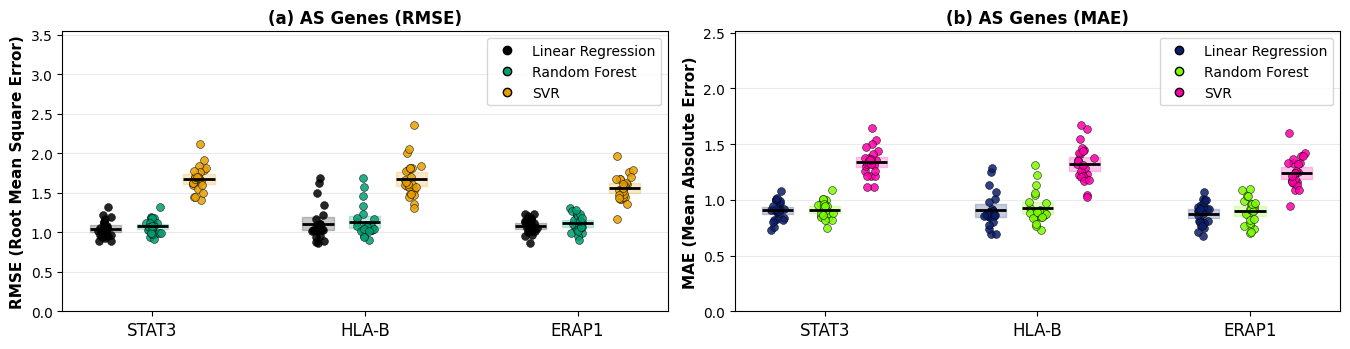

In [10]:
# Combined figure: RMSE and MAE subfigures for paper (full page width)
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
from os.path import join

_model_colors = {
    "rmse": {
        'LinearRegression': '#000000',
        'RandomForestRegressor': '#009E73',
        'SVR': '#E69F00'
    },
    "mae": {
        'LinearRegression': '#0B1E6B',
        'RandomForestRegressor': '#7CFC00',
        'SVR': '#FF00A8'
    }
}
_model_labels = {
    'LinearRegression': 'Linear Regression',
    'RandomForestRegressor': 'Random Forest',
    'SVR': 'SVR'
}
_models_list = ['LinearRegression', 'RandomForestRegressor', 'SVR']

def _draw_dotplot_ax(ax, results_df, genes_list, metric, model_colors, y_label):
    n_genes = len(genes_list)
    width = 0.22
    global_max = 0.0

    for i, gene in enumerate(genes_list):
        for j, model in enumerate(_models_list):
            data = results_df[
                (results_df['gene'] == gene) &
                (results_df['model'] == model)
            ][metric].values

            if len(data) == 0:
                continue

            mean_val = float(np.mean(data))
            std_val = float(np.std(data, ddof=1)) if len(data) > 1 else 0.0
            n = len(data)
            ci = (1.96 * std_val / np.sqrt(n)) if n > 1 else 0.0
            global_max = max(global_max, mean_val + ci, float(np.max(data)))

            x = i + j * width
            color = model_colors.get(model, '#333333')

            np.random.seed(42 + i * 10 + j)
            x_jitter = x + np.random.normal(0, width * 0.08, size=len(data))

            ax.scatter(x_jitter, data, s=32, alpha=0.85, color=color,
                       edgecolor='black', linewidth=0.4, zorder=3)
            ax.hlines(mean_val, x - width / 3, x + width / 3,
                      colors='black', linewidth=2.0, zorder=4)
            if ci > 0:
                ax.fill_between([x - width / 3, x + width / 3],
                                mean_val - ci, mean_val + ci,
                                color=color, alpha=0.22, zorder=2)

    ax.set_ylabel(y_label, fontsize=11, fontweight='bold')
    gene_centers = [i + width for i in range(n_genes)]
    ax.set_xticks(gene_centers)
    ax.set_xticklabels(genes_list, fontsize=12)
    ax.tick_params(axis='y', labelsize=10)

    legend_elements = [
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=model_colors[m], markeredgecolor='black',
               markersize=6, label=_model_labels[m])
        for m in _models_list
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, alpha=0.25, axis='y')
    if global_max <= 0:
        global_max = 1.0
    ax.set_ylim(0, global_max * 1.5)
    ax.set_facecolor("white")


fig, axes = plt.subplots(1, 2, figsize=(13.6, 3.6))
fig.patch.set_facecolor("white")

_draw_dotplot_ax(axes[0], results_df, as_gene_names, "rmse",
                 _model_colors["rmse"], "RMSE (Root Mean Square Error)")
_draw_dotplot_ax(axes[1], results_df, as_gene_names, "mae",
                 _model_colors["mae"], "MAE (Mean Absolute Error)")

#axes[0].set_title("(a) Cross-disease Tranfer Learning (CD Genes, RMSE)", fontsize=12, fontweight='bold', pad=6)
#axes[1].set_title("(b) Cross-disease Tranfer Learning (CD Genes, MAE)", fontsize=12, fontweight='bold', pad=6)

axes[0].set_title("(a) AS Genes (RMSE)", fontsize=12, fontweight='bold', pad=6)
axes[1].set_title("(b) AS Genes (MAE)", fontsize=12, fontweight='bold', pad=6)


plt.tight_layout()

# combined_png = join(plot_output_dir, "k5_cluster_as_dotplot_combined.png")
# combined_png = join(plot_output_dir, "figure_11.png")
# plt.savefig(combined_png, dpi=300, bbox_inches='tight', facecolor="white")
# print(f"Saved: {combined_png}")
plt.show()
